In [110]:
! pip install scikit-fuzzy
! pip uninstall numpy -yq
! pip install numpy==1.26.4

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [132]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

from transformers import pipeline
import openai

from dotenv import load_dotenv
import os

load_dotenv()

openai.api_key = os.getenv("OPENAI_API_KEY")

# Fuzzy logic-based agent for negotiating prices in second hand markets

## Inputs
- Tono del comprador: Si el tono del comprador es colaborativo y amistoso, neutral o algo más agresivo e insistente.
    - Utilizaremos modelo zero-shot learning con tres características personalizadas. Obtendremos un valor para cada una de las tres etiquetas y para obtener el valor continuo haremos una ponderación utilizando los valores de las funciones de pertenencia y la distribución de probabildiades que devuelve el transformer
- Diferencia relativa entre el precio ofertado por el comprador y el precio ofertado por el vendedor. Esta función de pertenencia la obtenemos imitando la del paper.
- Duración de la negociación (número de interacciones). Contamos el número de intercambios de mensajes entre el comprador y el vendedor.

In [112]:
# zero shot classification for the buyers's tone

def get_tone_score(message):

    pipe = pipeline("zero-shot-classification",
                    model="facebook/bart-large-mnli")

    results = pipe(message,
        # candidate_labels=["friendly, collaborative", "neutral", "agressive, rude, insistent"],
        candidate_labels=["friendly", "neutral", "agressive"],
    )

    print(results)

    mappings = {label:score for label,score in zip(results["labels"],results['scores'])}
    tono_score = 0*mappings["friendly"] + 5*mappings["neutral"] + 10*mappings["agressive"]
    
    return tono_score

message = "un placer hacer negocios con usted"
tono_score = get_tone_score(message)
print(tono_score)

Device set to use cuda:0


{'sequence': 'un placer hacer negocios con usted', 'labels': ['friendly', 'neutral', 'agressive'], 'scores': [0.7298038005828857, 0.2432633489370346, 0.026932761073112488]}
1.485644355416298


In [ ]:
# extract the offered price
def extract_price(message):
    # Assuming the price is always preceded by a dollar sign
    price = message.split('$')[-1].split()[0]
    return float(price)

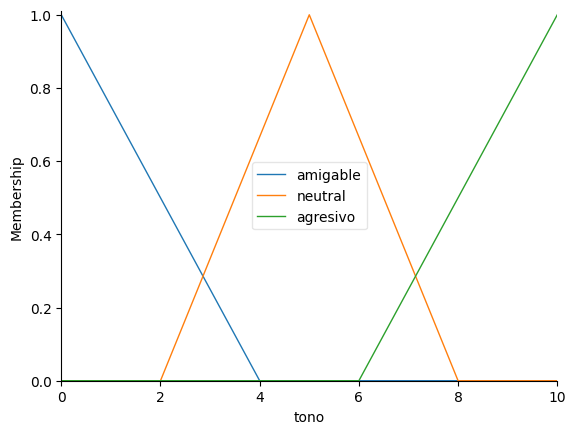

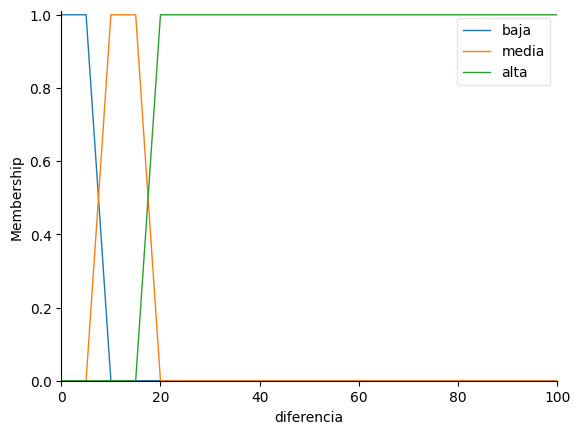

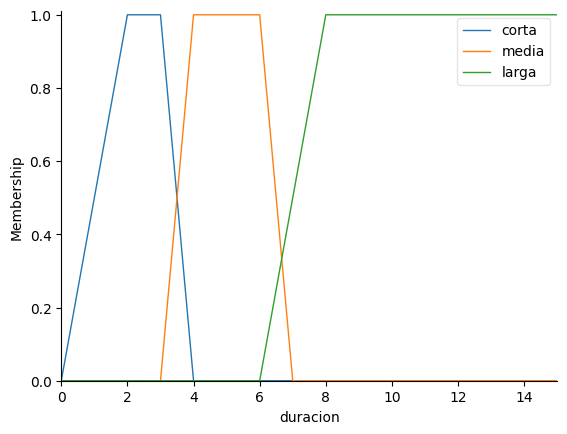

In [113]:
# Define the system inputs 
tono = ctrl.Antecedent(np.arange(0, 11, 1), 'tono')
diferencia = ctrl.Antecedent(np.arange(0, 101, 1), 'diferencia')
duracion = ctrl.Antecedent(np.arange(0, 16, 1), 'duracion')

# membership functions

# Se asume que 0 representa el extremo más amigable y 10 el más agresivo
tono['amigable'] = fuzz.trimf(tono.universe, [0, 0, 4])
tono['neutral']   = fuzz.trimf(tono.universe, [2, 5, 8])
tono['agresivo']  = fuzz.trimf(tono.universe, [6, 10, 10])

diferencia['baja'] = fuzz.trapmf(diferencia.universe, [0, 0, 5, 10])
diferencia['media'] = fuzz.trapmf(diferencia.universe, [5, 10, 15, 20])
diferencia['alta'] = fuzz.trapmf(diferencia.universe, [15, 20, 100, 100])

duracion['corta'] = fuzz.trapmf(duracion.universe, [0, 2, 3, 4])
duracion['media'] = fuzz.trapmf(duracion.universe, [3, 4, 6, 7])
duracion['larga'] = fuzz.trapmf(duracion.universe, [6, 8, 15, 15])

# plot the membership functions
tono.view()
diferencia.view()
duracion.view()

## System output

Desfuzzificaremos la salida como una variable continua llamada "grado de aceptación". En función de este grado de aceptación tomaremos diferentes decisiones. Las acciones posibles que quiero que tome mi sistema son:
- Aceptar: Acceder a la oferta del comprador y cerrar el trato (Fin de la simulación).
- Contraoferta: Ofrecer una contraoferta que se encuentre entre medias del precio original y el del vendedor.
- Mantener: Mantener el precio ofertado e informar de que no va a bajar de ese precio.
- Rechazar: Informar de que no estás dispuesto a negociar más y que no hay trato (Fin de la simulación)

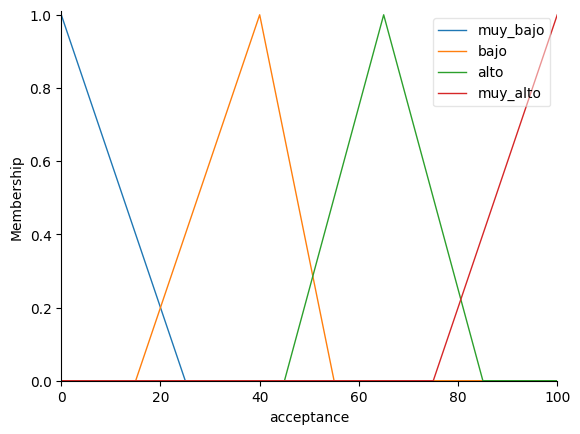

In [114]:
# La salida puede interpretarse de forma continua (por ejemplo, como grado de aceptación)
# A partir de esta variable continua tomamos decisiones discretas

acceptance = ctrl.Consequent(np.arange(0, 101, 1), 'acceptance')

acceptance['muy_bajo'] = fuzz.trimf(acceptance.universe, [0, 0, 25]) # -> Rechazar (terminar negociación)
acceptance['bajo'] = fuzz.trimf(acceptance.universe, [15, 40, 55]) # -> Mantener el precio (seguir negociando)
acceptance['alto'] = fuzz.trimf(acceptance.universe, [45, 65, 85]) # -> Ofrecer contraoferta (seguir negociando)
acceptance['muy_alto'] = fuzz.trimf(acceptance.universe, [75, 100, 100]) # -> Aceptar (cerrar trato)

acceptance.view()


## Rules

Definiremos las normas basadas en algunos principios de conocimiento experto en técnicas de negociación. En este sistema tan solo tenemos 3 entradas. Cada una de ellas puede tomar 3 valores posibles, con lo cual, tendríamos un total de 27 reglas:

| Tono del Comprador | Diferencia Relativa de Precio | Duración de Negociación | Acción |
|---------------------|------------------------------|-----------------------------------------|-----|
| Amigable           | Baja                         | Corta                                   | Aceptar |
| Amigable           | Baja                         | Media                                   | Aceptar |
| Amigable           | Baja                         | Larga                                   | Contraoferta |
| Amigable           | Media                        | Corta                                   | Contraoferta |
| Amigable           | Media                        | Media                                   | Contraoferta |
| Amigable           | Media                        | Larga                                   | Mantener |
| Amigable           | Alta                         | Corta                                   | Contraoferta |
| Amigable           | Alta                         | Media                                   | Mantener |
| Amigable           | Alta                         | Larga                                   | Rechazar |
| Neutral            | Baja                         | Corta                                   | Aceptar |
| Neutral            | Baja                         | Media                                   | Aceptar |
| Neutral            | Baja                         | Larga                                   | Contraoferta |
| Neutral            | Media                        | Corta                                   | Contraoferta |
| Neutral            | Media                        | Media                                   | Mantener |
| Neutral            | Media                        | Larga                                   | Mantener |
| Neutral            | Alta                         | Corta                                   | Mantener |
| Neutral            | Alta                         | Media                                   | Mantener |
| Neutral            | Alta                         | Larga                                   | Mantener |
| Agresivo           | Baja                         | Corta                                   | Mantener |
| Agresivo           | Baja                         | Media                                   | Mantener |
| Agresivo           | Baja                         | Larga                                   | Rechazar |
| Agresivo           | Media                        | Corta                                   | Mantener |
| Agresivo           | Media                        | Media                                   | Mantener |
| Agresivo           | Media                        | Larga                                   | Rechazar |
| Agresivo           | Alta                         | Corta                                   | Rechazar |
| Agresivo           | Alta                         | Media                                   | Rechazar |
| Agresivo           | Alta                         | Larga                                   | Rechazar |

In [115]:
# Reglas para tono 'amigable'
rule_A1 = ctrl.Rule(tono['amigable'] & diferencia['baja'] & (duracion['corta'] | duracion['media']), acceptance['muy_alto'])
rule_A2 = ctrl.Rule(tono['amigable'] & diferencia['baja'] & duracion['larga'], acceptance['alto'])
rule_A3 = ctrl.Rule(tono['amigable'] & diferencia['media'] & (duracion['corta'] | duracion['media']), acceptance['alto'])
rule_A4 = ctrl.Rule(tono['amigable'] & diferencia['media'] & duracion['larga'], acceptance['bajo'])
rule_A5 = ctrl.Rule(tono['amigable'] & diferencia['alta'] & duracion['corta'], acceptance['alto'])
rule_A6 = ctrl.Rule(tono['amigable'] & diferencia['alta'] & duracion['media'], acceptance['bajo'])
rule_A7 = ctrl.Rule(tono['amigable'] & diferencia['alta'] & duracion['larga'], acceptance['muy_bajo'])

# Reglas para tono 'neutral'
rule_N1 = ctrl.Rule(tono['neutral'] & diferencia['baja'] & (duracion['corta'] | duracion['media']), acceptance['muy_alto'])
rule_N2 = ctrl.Rule(tono['neutral'] & diferencia['baja'] & duracion['larga'], acceptance['alto'])
rule_N3 = ctrl.Rule(tono['neutral'] & diferencia['media'] & duracion['corta'], acceptance['alto'])
rule_N4 = ctrl.Rule(tono['neutral'] & diferencia['media'] & (duracion['media'] | duracion['larga']), acceptance['bajo'])
rule_N5 = ctrl.Rule(tono['neutral'] & diferencia['alta'], acceptance['bajo'])  # Aplica para cualquier duración

# Reglas para tono 'agresivo'
rule_AG1 = ctrl.Rule(tono['agresivo'] & diferencia['baja'] & (duracion['corta'] | duracion['media']), acceptance['bajo'])
rule_AG2 = ctrl.Rule(tono['agresivo'] & diferencia['baja'] & duracion['larga'], acceptance['muy_bajo'])
rule_AG3 = ctrl.Rule(tono['agresivo'] & diferencia['media'] & (duracion['corta'] | duracion['media']), acceptance['bajo'])
rule_AG4 = ctrl.Rule(tono['agresivo'] & diferencia['media'] & duracion['larga'], acceptance['muy_bajo'])
rule_AG5 = ctrl.Rule(tono['agresivo'] & diferencia['alta'], acceptance['muy_bajo'])  # Aplica para cualquier duración

# (17 reglas en total)
rules = [rule_A1, rule_A2, rule_A3, rule_A4, rule_A5, rule_A6, rule_A7,
         rule_N1, rule_N2, rule_N3, rule_N4, rule_N5,
         rule_AG1, rule_AG2, rule_AG3, rule_AG4, rule_AG5]

Mis notas:
- Por lo general, si el tono es amistoso y la diferencia de preio es baja, esto puede indicar buena fe del comprador y nos facilita buscar el mayor beneficio de ambas partes. En el caso excepcional de que la negociación esté siendo muy larga, puede ser que el comprador esté testeando nuestros límites o buscando más concesiones. En este caso, aceptar puede reforzar un comportamiento de "esperar hasta que cedas", por lo que lo mejor sería hacer una contraoferta razonable. Recordemos que el comprador está siendo amistoso y nos ha ofrecido un precio muy razonable, por lo que cerrarnos en banda de pronto e informar de que no vamos a bajar el precio puede generar descontento y provocar que una venta que parecía casi segura no se realice.
    - Puede usar tono amistoso como técnica persuasiva mientras sigue buscando bajar el precio.
    💡 Zig Ziglar advierte sobre esto: no confundas amabilidad con intenciones justas.

- Si la diferencia es media y el tono es amistoso nunca aceptaremos de primeras. La persona puede estar abierta a negociar y podemos ofrecer un trato más justo.
    - Dale Carnegie diría: valora las relaciones, pero no dejes que la amabilidad nuble el juicio.
    - Grant Cardone te diría: "el hecho de que alguien sea simpático no significa que debas bajar tu precio."
    - Si la negociación ha sido larga → el comprador podría estar agotando tu voluntad o intentando manipularte.

- Si la diferencia es alta y el tono es amistoso puede que estemos ante un negociador experto que trata de manipularnos y es posible que haya que ir con cuidado. Aplicamos los mismos puntos que en el punto anterior, que alguien sea amjo no significa que tengamos que ceder. No ceder y mantenerse firme también refuerza la credibilidad y la confianza en nuestro producto.

- Si el tono es neutral, entonces estamos en una negociación estándar. Un tono neutral es equilibrado, racional, sin emociones aparentes, ni de colaboración ni de confrontación.
    - Comunicación directa, sin adornos.
    - No hay señales de urgencia ni presión.
    - No busca conectar emocionalmente.
    - A menudo centrado en hechos, datos o lógica.
    - En muchos casos, el tono neutral es una estrategia deliberada: mantenerse impredecible o proteger intereses.
- Un tono neutral y baja diferencia indican que probablemente el comprador solo quiere validar su decisión, no presionar.
    - De forma similar al tono amistoso, aceptamos si la duración es baja o media, y hacemos uan contraoferta si la duración es larga, para evitar que nos apliquen una estrategia de desgaste
- si la diferencia de precio es alta y la duración es larga asumimos que el comprador es suficientemente racional para abandonar la negociación, no nos cerramos al trato a diferencia de cuando el tono amistoso porque asumimos que no nos están intentando manipular, y puede que perdamos un cliente de forma innecesaria. 
    - Conviene rechazar si el tono es agresivo y manipulador, pero no si es neutral. 
    - Dejamos la puerta abierta sin debilitarnos.


- Si el comprador es agresivo:
    - Interrumpir, presionar o usar lenguaje dominante.
    - Lanzar amenazas sutiles (“me voy a otro proveedor”).
    - Hacer exigencias poco razonables desde el principio.
    - Mostrar impaciencia o intentar ponerte a la defensiva.
    - tonos más de urgencia e insistencia
    - no tiene por qué haber faltas de respeto ni maldad, a veces es simplemente la forma en la que el comprador ha aprendido a negociar.

    - No recompenses la agresividad con concesiones. Grant Cardone diría: “Si cedes ante la presión, perderás el respeto del cliente y del mercado.”
    - Mantén el control emocional. Zig Ziglar sugería “cerrar desde la calma”, incluso si el otro está alterado. No caigas en su juego.
    - Aplica firmeza sin cerrar puertas innecesarias. Dale Carnegie lo expresaría así: “Sé firme en lo esencial, flexible en la forma.”
    - Usa el tiempo a tu favor. Si ves que el comprador no afloja y el trato se alarga, probablemente no vale la pena seguir.

- Si el comprador es agresivo nunca haremos una contraoferta. Debemos mantenernos firmes y no reforzar la conducta agresiva, perdiendo autoridad y control. Además, si mostramos debilidad, puede que nos siga presionando, ganando terreno y bajando todavía más el precio.
- En Getting to Yes, Fisher y Ury explican que para que una negociación funcione debe basarse en Intereses mutuos, Criterios objetivos, Respeto interpersonal. Si el comprador rompe esas bases, no tiene sentido aplicar técnicas de "construcción de acuerdos" como las contraofertas.
- ¿Hay excepciones? Sí, pero son pocas. Podrías hacer una contraoferta estratégica en caso de comprador agresivo si detectas que su estilo no es personal, sino cultural o mecánico (por ejemplo, algunos compradores B2B que “siempre negocian duro”). Pero incluso en esos casos, lo ideal es que la contraoferta venga después de que él rebaje el tono o tú establezcas límites claros.

Reglas:
- Nunca aceptar una oferta agresiva, aunque sea buena.
- Mantener cuando hay espacio lógico, pero con comunicación firme.
- Rechazar sin miedo cuando hay toxicidad, falta de respeto o intento de manipulación.
- No responder con la misma actitud. Eso te saca del rol de autoridad.

Actuaremos así: Mantener el precio hasta que la duración sea muy larga (demasiado esfuerzo, desgaste y toxicidad). Si de primeras el tono es agresivo y además la diferencia de precio es muy alta entonces cortamos de inmediato la negociación por tiempo invertido, poca probabilidad de llegar a un acuerdo, el comprador no valora mi propuesta, etc.

## Simple example

In [118]:
mensaje = "hola lo quiero 19"
original_price = 20
price_offered = 19

duracion_actual = 1
diferencia_relativa = abs(price_offered - original_price) / original_price * 100
tono_value = get_tone_score(mensaje)

Device set to use cuda:0


{'sequence': 'hola lo quiero 19', 'labels': ['friendly', 'agressive', 'neutral'], 'scores': [0.5861033201217651, 0.4027387499809265, 0.011157983914017677]}


In [121]:
def map_action(accion):
    if accion <= 20:
        return "Rechazar"
    elif accion <= 50:
        return "Mantener"
    elif accion <= 80:
        return "Contraoferta"
    else:
        return "Aceptar"

Valores de entrada:
Tono: 4.0831774193793535
Diferencia relativa: 5.0
Duración: 1
Mensaje: hola lo quiero 19
Valor resultante (índice de acción): 90.27777777777777


/home/rjvillen/.local/lib/python3.10/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


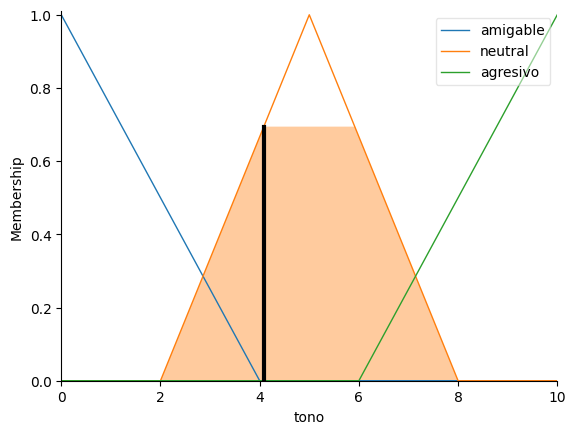

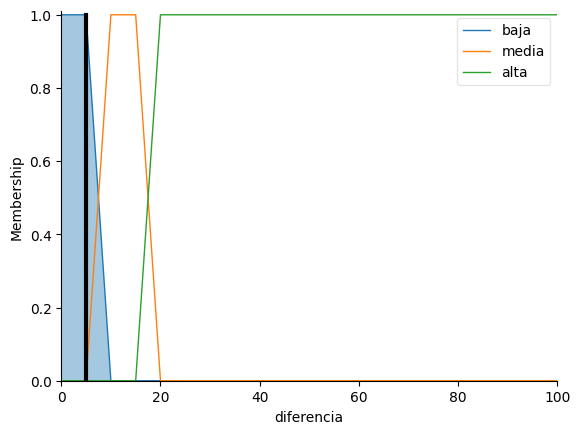

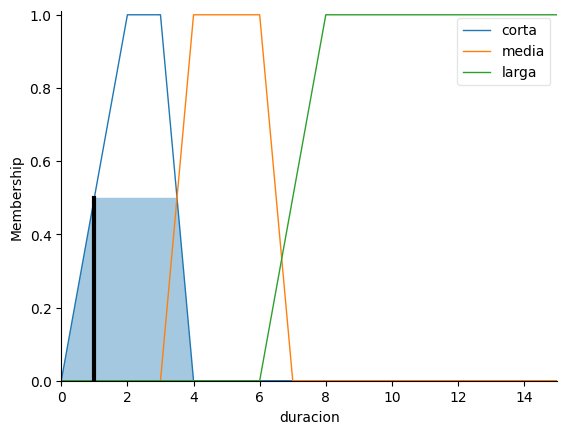

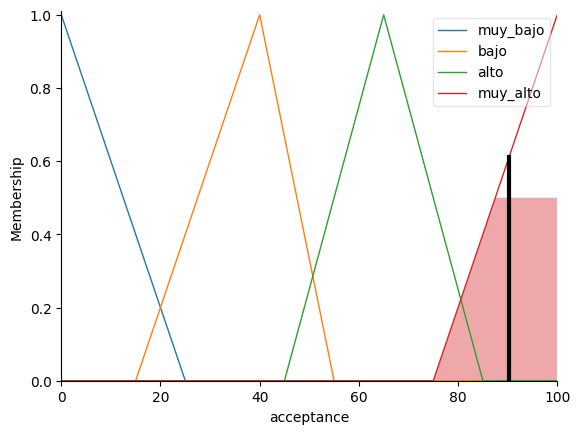

In [124]:
negotiation_ctrl = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(negotiation_ctrl)

print("Valores de entrada:")
print("Tono:", tono_value)
print("Diferencia relativa:", diferencia_relativa)
print("Duración:", duracion_actual)
print("Mensaje:", mensaje)

simulation.input['tono'] = tono_value
simulation.input['diferencia'] = diferencia_relativa
simulation.input['duracion'] = duracion_actual

simulation.compute()

accion = simulation.output['acceptance']
print("Valor resultante (índice de acción):", accion)

# visualization of the output membership
tono.view(sim=simulation)
diferencia.view(sim=simulation)
duracion.view(sim=simulation)
acceptance.view(sim=simulation)

## Real Case

In [ ]:
def generar_respuesta_vendedor(message, accion_difusa, context):

    system_prompt = """Eres un vendedor experto en negociaciones por chat. Eres conciso y profesional.
    
    Recibirás mensajes con esta estructura:
    - Mensaje del comprador: [mensaje]
    - Precio original: [precio]
    - Acción que debes tomar: [acción]
    - Precio ofertado por el comprador: [precio ofertado]
    
    La acción está determinada por un sistema difuso que tiene en cuenta el tono del comprador, la diferencia relativa entre el ofertado 
    por el vendedor y el precio ofertado por el comprador.
    
    Las acciones que se te manden pueden ser únicamente una de estas:
    - Aceptar: En ese caso, debes aceptar la oferta del comprador y cerrar el trato.
    - Mantener: En este caso, debes mantenerte firme con el precio original, no aceptar la oferta del comprador e indicarle amablemente que
    no tienes pensado bajar más tu precio.
    - Contraoferta: En este caso, debes ofrecer una contraoferta al comprador. Puedes ofrecer un precio ligeramente más bajo que el original,
    pero nunca inferior al 15% del precio original, y superior al precio ofertado por el comprador.
    - Rechazar: En este caso, debes rechazar la oferta del comprador e indicar educamente que no estás dispuesto a negociar más porque no llegaréis
    a un acuerdo beneficioso para ambos.
    
    Tu tarea consiste en generar un mensaje de respuesta para el comprador, utilizando obligatoriamente la acción que se te indica."""
    
    user_prompt = f'''
    Mensaje del comprador: {message}'
    Precio original: {context['precio_original']}
    Acción que debes tomar: {accion_difusa}
    Precio ofertado por el comprador: {context['precio_ofertado']}
    '''
    
    try:
        # Aquí se puede usar la API de OpenAI o cualquier otro modelo de lenguaje
        response = openai.ChatCompletion.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ]
        )
        
        respuesta = response['choices'][0]['message']['content']
        return respuesta
    except Exception as e:
        return f"Error al generar respuesta con LLM: {e}"

In [136]:
context = {
    "precio_original": original_price,
    "precio_ofertado": price_offered
}
accion_difusa = map_action(accion)

generar_respuesta_vendedor(message=message, accion_difusa=accion_difusa, context=context)

'Error al generar respuesta con LLM: \n\nYou tried to access openai.ChatCompletion, but this is no longer supported in openai>=1.0.0 - see the README at https://github.com/openai/openai-python for the API.\n\nYou can run `openai migrate` to automatically upgrade your codebase to use the 1.0.0 interface. \n\nAlternatively, you can pin your installation to the old version, e.g. `pip install openai==0.28`\n\nA detailed migration guide is available here: https://github.com/openai/openai-python/discussions/742\n'

dudas idif:
- estan bien las funciones de pertenencia que he seguido?
- está bien la forma en la que estoy tratando la salida del transformer?
- la salida puede ser una acción y está bien cómo la estoy definiendo? cambios en la función de pertenencia de la salida?
- tomar la decisión con mayor pertenencia y ya? o dejar que el llm razone con todos los valores?

otras fuentes además de papers:
- https://oleg-dubetcky.medium.com/mastering-fuzzy-logic-in-multi-agent-llm-analysis-system-b2889e1e8500
- Conversación para crear reglas con conocimiento experto: https://chatgpt.com/share/67fa3358-d004-8005-adb6-19e3d7bcd2ab